In [1]:
import pandas as pd
import re
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.affinity import translate
import numpy as np

# Mapping out Labor Demand

In [2]:
filepath = 'data/ABDD-Phase1B.xlsx'
df = pd.read_excel(filepath, sheet_name=2)
useful_columns = df.columns[df.columns.str.contains('Useful')]
df = df[useful_columns]

In [3]:
# Define your column names
cols = [
    'Region', 'Province', 'District', 'Sector', 'Subsector',
    'Job Requirement', 'Program', 'Type of Program', 'Demand'
]

# Create an empty list to collect all expanded DataFrames
expanded_list = []

for col in df.columns:
    # Split, filter, and expand in one clean pipeline
    expanded_df = (
        df[col]
        .dropna()                                    # drop missing
        .loc[lambda x: x.str.startswith('REGION_VII')]  # keep only REGION_VII
        .apply(lambda s: re.split(r'\|+', s))        # split by | or ||
        .loc[lambda x: x.apply(len) == len(cols)]    # keep only lists of length 9
        .apply(pd.Series, index=cols)                # convert to DataFrame
        .reset_index(drop=True)                      # tidy index
    )

    expanded_list.append(expanded_df)


# Concatenate the dataframes
jobs_df = pd.concat(expanded_list, ignore_index=True)

# Clean up the priority column
jobs_df = jobs_df[jobs_df['Demand'] != '']
jobs_df['Demand'] = pd.Categorical(
    jobs_df['Demand'],
    categories=['LOW', 'MEDIUM', 'HIGH'],
    ordered=True
)

# Filter for only the edcom-defined tourism sectors
#jobs_df = jobs_df[jobs_df['Sector'].isin(['CONSTRUCTION', 'MANUFACTURING', 'TOURISM (HOTEL AND RESTAURANT)'])]


In [4]:
jobs_df.groupby(['District', 'Program'])['Demand'].value_counts()

District                       Program                         Demand
Cebu City, District 1          2D ANIMATION NC III             LOW       2
                                                               MEDIUM    0
                                                               HIGH      0
                               2D GAME ART DEVELOPMENT NC III  LOW       1
                                                               MEDIUM    0
                                                                        ..
Lapu-Lapu City, Lone District  WAREHOUSING SERVICES NC II      LOW       0
                                                               MEDIUM    0
                               WEB DEVELOPMENT NC III          MEDIUM    5
                                                               LOW       2
                                                               HIGH      0
Name: count, Length: 5760, dtype: int64

In [76]:
summary = (
    jobs_df
    .groupby(['District', 'Program'])['Demand']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

summary

Demand,District,Program,LOW,MEDIUM,HIGH
0,"Cebu City, District 1",2D ANIMATION NC III,2,0,0
1,"Cebu City, District 1",2D GAME ART DEVELOPMENT NC III,1,0,0
2,"Cebu City, District 1",3D ANIMATION NC III,1,0,0
3,"Cebu City, District 1",3D GAME ART DEVELOPMENT NC III,1,0,0
4,"Cebu City, District 1",AGRICULTURAL CROPS PRODUCTION NC II,1,0,0
...,...,...,...,...,...
1915,"Lapu-Lapu City, Lone District",TRAINERS METHODOLOGY LEVEL II (TRAINING DESIGN...,1,0,0
1916,"Lapu-Lapu City, Lone District",VIRTUAL ASSISTANT SERVICES LEVEL III,1,0,0
1917,"Lapu-Lapu City, Lone District",VISUAL GRAPHIC DESIGN NC III,3,5,0
1918,"Lapu-Lapu City, Lone District",WAREHOUSING SERVICES NC II,0,0,2


In [71]:
jobs_df.groupby(['District', 'Program'])['Demand']

In [4]:
jobs_df['Sector'].nunique()

16

In [5]:
jobs_df.groupby('Sector')['Type of Program'].count()

Sector
AGRICULTURE FORESTRY AND FISHERY                     151
AUTOMOTIVE AND LAND TRANSPORTATION                   128
CONSTRUCTION                                        1045
CREATIVE SECTOR                                       86
ELECTRICAL & ELECTRONICS                              20
ENERGY                                               140
GARMENTS                                              10
HUMAN HEALTH / HEALTH CARE                           259
INFORMATION AND COMMUNICATION TECHNOLOGY             600
MANUFACTURING                                        543
MARITIME                                              20
METALS AND ENGINEERING                               240
PROCESSED FOOD & BEVERAGES                            10
SOCIAL, COMMUNITY DEVELOPMENT AND OTHER SERVICES      80
TOURISM (HOTEL AND RESTAURANT)                       365
TVET                                                 820
Name: Type of Program, dtype: int64

In [6]:
conservative_mapping = {'LOW':10, 'MEDIUM':100, 'HIGH':250, '':0}
expected_mapping = {'LOW':30, 'MEDIUM':150, 'HIGH':350, '':0}
best_mapping = {'LOW':50, 'MEDIUM':250, 'HIGH':500, '':0}
jobs_df['Conservative Demand'] = jobs_df['Demand'].apply(lambda x : conservative_mapping[x]).astype(int)
jobs_df['Expected Demand'] = jobs_df['Demand'].apply(lambda x : expected_mapping[x]).astype(int)
jobs_df['Best Demand'] = jobs_df['Demand'].apply(lambda x : best_mapping[x]).astype(int)

In [7]:
# Load shapefile
gdf = gpd.read_file("PH_Adm3_MuniCities.shp/Municities.shp.shp")

corr_code_to_district = {
    # 1st District
    "72232000": "1st District",  # Minglanilla
    "72246000": "1st District",  # Sibonga
    "72241000": "1st District",  # San Fernando
    "72214000": "1st District", # Carcar
    "72234000": "1st District", # Naga
    "72250000": "1st District", # Talisay
    # 2nd District
    "72202000": "2nd District",  # Alcoy
    "72205000": "2nd District",  # Argao
    "72212000": "2nd District",  # Boljoon
    "72222000": "2nd District",  # Dalaguete
    "72235000": "2nd District",  # Oslob
    "72240000": "2nd District",  # Samboan
    "72245000": "2nd District",  # Santander
    # 3rd District
    "72204000": "3rd District",  # Aloguinsan
    "72206000": "3rd District",  # Asturias
    "72208000": "3rd District",  # Balamban
    "72210000": "3rd District",  # Barili
    "72237000": "3rd District",  # Pinamungajan
    "72252000": "3rd District",  # Tuburan
    "72251000": "3rd District",  # Toledo
    # 4th District
    "72209000": "4th District",  # Bantayan
    "72221000": "4th District",  # Daanbantayan
    "72228000": "4th District",  # Madridejos
    "72231000": "4th District",  # Medellin
    "72243000": "4th District",  # San Remigio
    "72244000": "4th District",  # Santa Fe
    "72248000": "4th District",  # Tabogon
    "72249000": "4th District",  # Tabuelan
    "72211000": "4th District", # Bogo
    # 5th District
    "72213000": "5th District",  # Borbon
    "72215000": "5th District",  # Carmen
    "72216000": "5th District",  # Catmon
    "72218000": "5th District",  # Compostela
    "72227000": "5th District",  # Liloan
    "72236000": "5th District",  # Pilar
    "72238000": "5th District",  # Poro
    "72242000": "5th District",  # San Francisco
    "72247000": "5th District",  # Sogod
    "72253000": "5th District",  # Tudela
    "72223000": "5th District", # Danao
    # 6th District
    "72219000": "6th District",  # Consolacion
    "72220000": "6th District",  # Cordova
    "72230000": "6th District", # Mandaue
    # 7th District
    "72201000": "7th District",  # Alcantara
    "72203000": "7th District",  # Alegria
    "72207000": "7th District",  # Badian
    "72224000": "7th District",  # Dumanjug
    "72225000": "7th District",  # Ginatilan
    "72229000": "7th District",  # Malabuyoc
    "72233000": "7th District",  # Moalboal
    "72239000": "7th District",  # Ronda
    # Cebu City
    "72217000": "City of Cebu",
    "72226000": "City of Lapu-Lapu",

    # Bohol Province
    # 1st District
    "71201000": "Bohol 1st District",  # Alburquerque
    "71204000": "Bohol 1st District",  # Antequera
    "71205000": "Bohol 1st District",  # Baclayon
    "71206000": "Bohol 1st District",  # Balilihan
    "71210000": "Bohol 1st District",  # Calape
    "71213000": "Bohol 1st District",  # Catigbian
    "71215000": "Bohol 1st District",  # Corella
    "71216000": "Bohol 1st District",  # Cortes
    "71219000": "Bohol 1st District",  # Dauis
    "71230000": "Bohol 1st District",  # Loon
    "71232000": "Bohol 1st District",  # Maribojoc
    "71233000": "Bohol 1st District",  # Panglao
    "71241000": "Bohol 1st District",  # Sikatuna
    "71245000": "Bohol 1st District",  # Tubigon
    "71242000": "Bohol 1st District",  # Tagbilaran City (component city)

    # 2nd District
    "71235000": "Bohol 2nd District",  # President Carlos P. Garcia
    "71239000": "Bohol 2nd District",  # Sevilla
    "71243000": "Bohol 2nd District",  # Talibon
    "71244000": "Bohol 2nd District",  # Trinidad
    "71246000": "Bohol 2nd District",  # Ubay
    "71237000": "Bohol 2nd District",  # San Isidro
    "71238000": "Bohol 2nd District",  # San Miguel
    "71226000": "Bohol 2nd District",  # Getafe
    "71218000": "Bohol 2nd District",  # Danao
    "71224000": "Bohol 2nd District",  # Inabanga
    "71209000": "Bohol 2nd District",  # Buenavista
    "71248000": "Bohol 2nd District",  # Bien Unido

    # 3rd District
    "71202000": "Bohol 3rd District",  # Alicia
    "71203000": "Bohol 3rd District",  # Anda
    "71207000": "Bohol 3rd District",  # Batuan
    "71208000": "Bohol 3rd District",  # Bilar
    "71211000": "Bohol 3rd District",  # Candijay
    "71212000": "Bohol 3rd District",  # Carmen
    "71214000": "Bohol 3rd District",  # Clarin
    "71217000": "Bohol 3rd District",  # Dagohoy
    "71220000": "Bohol 3rd District",  # Dimiao
    "71221000": "Bohol 3rd District",  # Duero
    "71223000": "Bohol 3rd District",  # Guindulman
    "71225000": "Bohol 3rd District",  # Jagna
    "71227000": "Bohol 3rd District",  # Lila
    "71228000": "Bohol 3rd District",  # Loay
    "71229000": "Bohol 3rd District",  # Loboc
    "71231000": "Bohol 3rd District",  # Mabini
    "71234000": "Bohol 3rd District",  # Pilar
    "71236000": "Bohol 3rd District",  # Sagbayan
    "71222000": "Bohol 3rd District",  # Garcia Hernandez
    "71240000": "Bohol 3rd District",  # Sierra Bullones
    "71247000": "Bohol 3rd District",  # Valencia
}

is_cebu = gdf["corr_code"].astype(str).str.startswith("722")
is_bohol = gdf["corr_code"].astype(str).str.startswith("712")
central_visayas_gdf = gdf[is_cebu | is_bohol].copy()
# Add a 'District' column to the GeoDataFrame
central_visayas_gdf["District"] = central_visayas_gdf["corr_code"].apply(lambda x : corr_code_to_district[str(x)[:-2]])


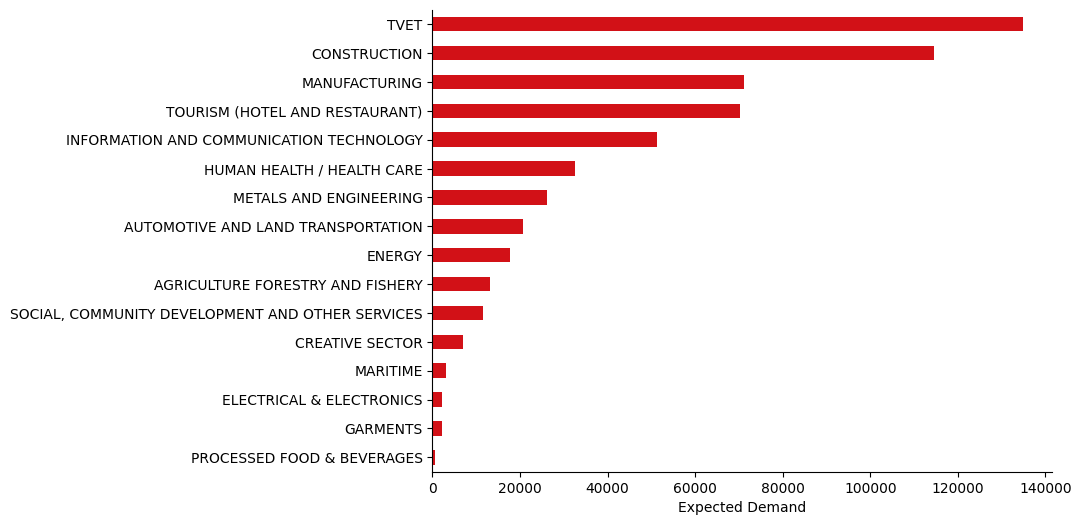

In [9]:
sectors_demand = jobs_df.groupby('Sector')['Expected Demand'].sum().sort_values(ascending=False)

# Step 4: Plot
sectors_demand.sort_values().plot(kind='barh', figsize=(8,6), color='#d21117')
plt.xlabel('Expected Demand')
plt.ylabel('')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()


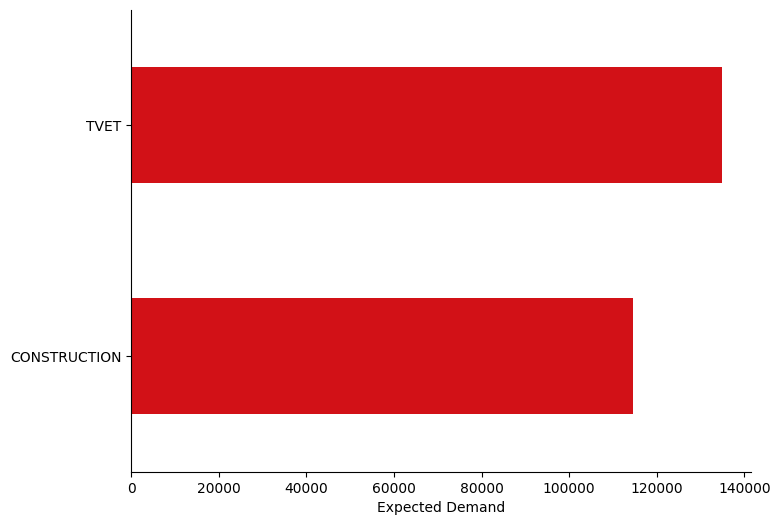

In [10]:
program_demand = jobs_df.groupby('Sector')['Expected Demand'].sum().sort_values(ascending=False)

# Step 2: Calculate cumulative percentage
cumulative_pct = program_demand.cumsum() / program_demand.sum()

# Step 3: Filter programs that contribute to the top 75%
top_75 = program_demand[cumulative_pct <= 0.5]

# Step 4: Plot
top_75.sort_values().plot(kind='barh', figsize=(8,6), color='#d21117')
plt.xlabel('Expected Demand')
plt.ylabel('')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()


In [11]:
jobs_df.groupby('District')['Expected Demand'].sum()

District
Cebu City, District 1            84180
Cebu City, District 2            67650
Cebu, District 1                 57120
Cebu, District 2                 49030
Cebu, District 3                 61180
Cebu, District 4                 48960
Cebu, District 5                 54600
Cebu, District 6                 53930
Cebu, District 7                 46950
Lapu-Lapu City, Lone District    55590
Name: Expected Demand, dtype: int64

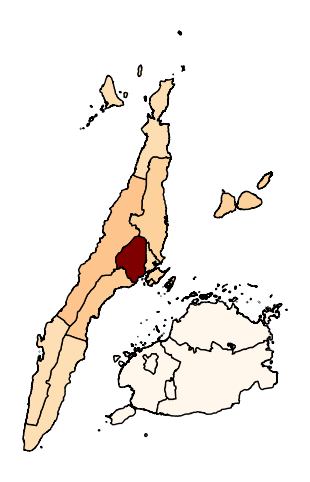

In [12]:
# 3Create example labor demand per district
labor_df = pd.DataFrame({
    "District": ["1st District", "2nd District", "3rd District", "4th District",
                 "5th District", "6th District", "7th District", "City of Cebu", "City of Lapu-Lapu", 
                 "Bohol 1st District", "Bohol 2nd District", "Bohol 3rd District"],
    "LaborDemand": [27250, 20460, 28890, 20740, 24970, 22500, 20230, 38750+29170, 23030, 9666, 9666, 9666]
})

# Dissolve municipalities into districts
district_gdf = central_visayas_gdf.dissolve(by="District", as_index=False)

# Merge labor demand
district_gdf = district_gdf.merge(labor_df, on="District")

# Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
district_gdf.plot(
    column="LaborDemand", 
    ax=ax, 
    #legend=True, 
    cmap="OrRd", 
    edgecolor="black",
)

#ax.set_title("Labor Demand per Legislative District of Region VII")
ax.axis("off")
plt.savefig('demand_choropleth.png', dpi=300, bbox_inches='tight')
plt.show()


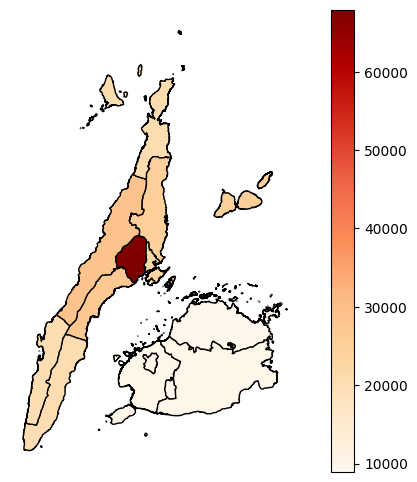

In [13]:
# 3Create example labor demand per district
labor_df = pd.DataFrame({
    "District": ["1st District", "2nd District", "3rd District", "4th District",
                 "5th District", "6th District", "7th District", "City of Cebu", "City of Lapu-Lapu", 
                 "Bohol 1st District", "Bohol 2nd District", "Bohol 3rd District"],
    "LaborDemand": [27250, 20460, 28890, 20740, 24970, 22500, 20230, 38750+29170, 23030, 9610, 8970, 9610]
})

# Dissolve municipalities into districts
district_gdf = central_visayas_gdf.dissolve(by="District", as_index=False)

# Merge labor demand
district_gdf = district_gdf.merge(labor_df, on="District")

# Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
district_gdf.plot(
    column="LaborDemand", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black",
)

#ax.set_title("Labor Demand per Legislative District of Region VII")
ax.axis("off")
#plt.savefig('demand_choropleth.png', dpi=300, bbox_inches='tight')
plt.show()


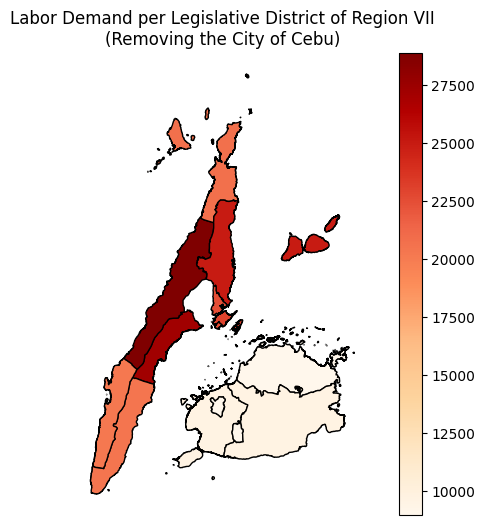

In [14]:
# Get Cebu City polygon
cebu_city = central_visayas_gdf[central_visayas_gdf["name"].str.contains("Cebu City", case=False)].copy()

# Combine with other districts
no_cebu_district_gdf = district_gdf[district_gdf["District"] != "City of Cebu"]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
no_cebu_district_gdf.plot(column="LaborDemand", ax=ax, legend=True, cmap="OrRd", edgecolor="black")
ax.set_title("Labor Demand per Legislative District of Region VII\n(Removing the City of Cebu)")
ax.axis("off")
plt.show()


# Mapping our Labor Supply and Just Getting the Tourism Related Sectors

In [40]:
NC_list = [
    # TOURISM
    "Barista NC II",
    "Bartending NC II",
    "Bread and Pastry Production NC II",
    "Cookery NC II",
    "Events Management Services NC III",
    "Food and Beverage Services NC II",
    "Food and Beverage Services NC III",
    "Food and Beverage Services NC IV",
    "Front Office Services NC II",
    "Housekeeping NC II",
    "Housekeeping NC III",
    "Housekeeping NC IV",
    "Local Guiding Services NC II",
    "Tour Guiding Services NC II",
    "Tourism Promotion Services NC II",
    "Tour Packaging (FIT Ad Hoc Domestic) Services NC II",
    "Travel Services NC II",

    # CONSTRUCTION
    "Carpentry NC II",
    "Carpentry NC III",
    "Construction Painting NC II",
    "Electrical Installation and Maintenance NC II",
    "Electrical Installation and Maintenance NC III",
    "Electrical Installation and Maintenance NC IV",
    "Heavy Equipment Operation (Backhoe Loader) NC II",
    "Heavy Equipment Operation (Bulldozer) NC II",
    "Heavy Equipment Operation (Concrete Pump) NC II",
    "Heavy Equipment Operation (Crawler Crane) NC II",
    "Heavy Equipment Operation (Crawler Crane) NC III",
    "Heavy Equipment Operation (Gantry Crane) NC II",
    "Heavy Equipment Operation (Motor Grader) NC II",
    "Heavy Equipment Operation (Overhead and Gantry Crane) NC III",
    "Heavy Equipment Operation (Road Roller) NC II",
    "Heavy Equipment Operation (Rough Terrain Crane) NC II",
    "Heavy Equipment Operation (Rough Terrain Crane) NC III",
    "Heavy Equipment Operation (Tower Crane) NC II",
    "Heavy Equipment Operation (Tower Crane) NC III",
    "Heavy Equipment Operation (Transit Mixer) NC II",
    "Heavy Equipment Operation (Truck Mounted Crane) NC II",
    "Heavy Equipment Operation (Truck Mounted Crane) NC III",
    "Heavy Equipment Operation (Wheel Loader) NC II",
    "Heavy Equipment Servicing (Mechanical) NC II",
    "Masonry NC I",
    "Masonry NC II",
    "Masonry NC III",
    "Plumbing NC I",
    "Plumbing NC II",
    "Plumbing NC III",
    "PV Systems Installation NC II",
    "PV Systems Servicing NC III",
    "Reinforcing Steel Works NC II",
    "Rigging NC I",
    "Scaffolding Works (Supported Type Scaffold) NC II",
    "System Formworks Installation NC II",
    "Tile Setting NC II",

    # MANUFACTURING
    "Automotive Body Repairing NC II",
    "Automotive Painting NC II",
    "CNC Lathe Machine Operation NC II",
    "CNC Milling Machine Operation NC II",
    "Electronic Products Assembly and Servicing NC II",
    "Flux-Cored Arc Welding (FCAW) NC II",
    "Gas Metal Arc Welding (GMAW) NC I",
    "Gas Metal Arc Welding (GMAW) NC II",
    "Gas Metal Arc Welding (GMAW) NC III",
    "Gas Tungsten Arc Welding (GTAW) NC II",
    "Instrumentation and Control Servicing NC II",
    "Instrumentation and Control Servicing NC III",
    "Machining NC I",
    "Machining NC II",
    "Mechatronics Servicing NC II",
    "Mechatronics Servicing NC III",
    "Mechatronics Servicing NC IV",
    "Pipefitting (Metallic) NC II",
    "Shielded Metal Arc Welding (SMAW) NC I",
    "Shielded Metal Arc Welding (SMAW) NC II",
    "Shielded Metal Arc Welding (SMAW) NC III",
    "Shielded Metal Arc Welding (SMAW) NC IV",
    "Technical Drafting NC II"
]

In [41]:
# open up the files and merge them
filepath = 'data/TESDA 2024 EGAC.xlsx'
num_supply_df = pd.read_excel(filepath, sheet_name=0)
num_supply_df = num_supply_df[num_supply_df['Qualification'].isin(NC_list)]

filepath = 'data/R7 TEDSA Schools_GGIS_ with ' \
'graduate count and municipality codes.csv'
loc_df = pd.read_csv(filepath)

supply_df = num_supply_df.merge(
    loc_df[['Provider Name', 'Municipality', 'lat', 'lon']],
    on='Provider Name',
    how='left'
).dropna()

geo_supply_df = supply_df.groupby('Provider Name', as_index=False).agg({
    'Graduates': 'sum',
    'Municipality': 'first',
    'Qualification': 'first',
    'lat': 'first',
    'lon': 'first'
})

# There was one outlier, so remove that
non_outlier = geo_supply_df['lat'].quantile(0.99)
supply_df_filtered = geo_supply_df[
    geo_supply_df['lat'] <= non_outlier
]

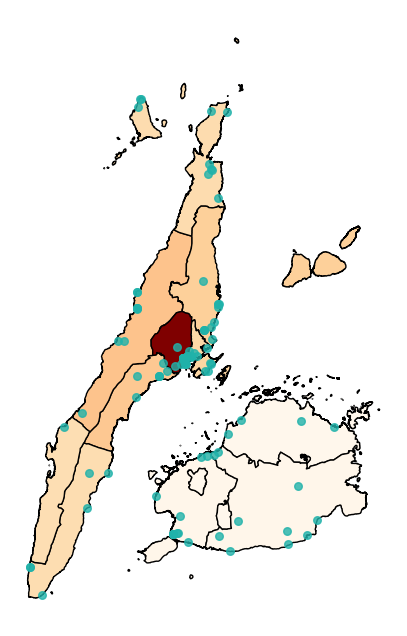

In [42]:
from shapely.geometry import Point

# Convert your school DataFrame (agg_df) into a GeoDataFrame
schools_gdf = gpd.GeoDataFrame(
    supply_df_filtered,
    geometry=gpd.points_from_xy(supply_df_filtered['lon'], supply_df_filtered['lat']),
    crs="EPSG:4326"  # WGS84 latitude/longitude
)

# Make sure the districts GeoDataFrame is in the same CRS
schools_gdf = schools_gdf.to_crs(district_gdf.crs)

# lot the districts choropleth
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
district_gdf.plot(
    column="LaborDemand",
    ax=ax,
    legend=False,
    cmap="OrRd",
    edgecolor="black"
)

# Overlay schools as blue points
schools_gdf.plot(
    ax=ax,
    alpha=0.8,
    color='lightseagreen',
    markersize=30,
    label="Schools"
)

# Finish up
ax.axis("off")
plt.savefig('choropleth.png', dpi=300, bbox_inches='tight')
plt.show()


In [43]:
district_mapping = {
    # Cebu City and nearby cities (lone districts)
    'Cebu City (Capital)': 'City of Cebu',
    'Mandaue City': 'City of Cebu',
    'Lapu-Lapu City (Opon)': 'City of Lapu-Lapu',
    
    # Cebu Province
    'Asturias': '1st District',
    'Balamban': '1st District',
    'Bogo City': '1st District',
    'Daanbantayan': '1st District',
    'Madridejos': '1st District',
    'Tabogon': '1st District',
    
    'Argao': '2nd District',
    'Dalaguete': '2nd District',
    'Samboan': '2nd District',
    
    'Toledo City': '3rd District',
    'Barili': '3rd District',
    'Carmen': '3rd District',
    'Dumanjug': '3rd District',
    
    'Minglanilla': '4th District',
    'City of Talisay': '5th District',
    'Danao City': '5th District',
    
    'Consolacion': '6th District',
    'Liloan': '6th District',
    
    'City of Naga': '7th District',
    'San Fernando': '7th District',
    
    # Bohol Province
    'Tagbilaran City': 'Bohol 1st District',
    'Baclayon': 'Bohol 1st District',
    'Clarin': 'Bohol 1st District',
    'Lila': 'Bohol 1st District',
    'Tubigon': 'Bohol 1st District',
    'Trinidad': 'Bohol 1st District',
    'Buenavista': 'Bohol 1st District',
    
    'Cortes': 'Bohol 2nd District',
    'Ubay': 'Bohol 2nd District',
    'Garcia Hernandez': 'Bohol 2nd District',
    'Duero': 'Bohol 2nd District',
    'Loboc': 'Bohol 2nd District',
    'Loon': 'Bohol 2nd District',
    'Bilar': 'Bohol 2nd District',
    'Jagna': 'Bohol 2nd District',
    'Pilar': 'Bohol 2nd District',
}

geo_supply_df['District'] = geo_supply_df['Municipality'].map(district_mapping)


In [44]:
geo_supply_df.groupby('Qualification').agg({
    'Graduates':sum,
    'Municipality':'first'
})['Graduates'].sort_values(ascending=False)

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_40998/3964936533.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  geo_supply_df.groupby('Qualification').agg({


Qualification
Bread and Pastry Production NC II                   8821
Barista NC II                                       1648
Carpentry NC II                                     1628
Events Management Services NC III                   1480
Cookery NC II                                        923
Heavy Equipment Operation (Bulldozer) NC II          869
Housekeeping NC II                                   622
Electrical Installation and Maintenance NC II        556
CNC Lathe Machine Operation NC II                    485
Electronic Products Assembly and Servicing NC II     458
Shielded Metal Arc Welding (SMAW) NC II              339
Gas Metal Arc Welding (GMAW) NC II                   208
Shielded Metal Arc Welding (SMAW) NC I               143
Food and Beverage Services NC II                     123
Bartending NC II                                      97
Instrumentation and Control Servicing NC II           91
Electrical Installation and Maintenance NC III        69
Reinforcing Steel

In [63]:
mapping_name_district = central_visayas_gdf[['name', 'District']]
egac_df = pd.read_csv('data/R7 TEDSA Schools_GGIS_ with graduate count and municipality codes.csv')
egac_districts_df = egac_df.merge(mapping_name_district, left_on='Municipality', right_on='name')
supply_df_with_districts_df = num_supply_df.merge(egac_districts_df, on='Provider Name')

df = supply_df_with_districts_df.groupby(['District', 'Qualification'])['Graduates_y'].sum()

df.loc['2nd District']

Qualification
Bread and Pastry Production NC II                 764
Cookery NC II                                    1266
Electrical Installation and Maintenance NC II     502
Housekeeping NC II                                980
Shielded Metal Arc Welding (SMAW) NC II           712
Name: Graduates_y, dtype: int64

In [64]:
df.index

MultiIndex([(      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '1st District', ...),
            (      '2nd District', ...),
            (      '2nd District', ...),
            (      '2nd District', ...),
            (      '2nd District', ...),
            (      '2nd District', ...),
            (      '3rd District', ...),
            (      '3rd District', ...),
            (      '3rd District', ...),
            (      '3rd District', ...),
            (      '3rd District', ...),
            (      '3rd District', ...),
            (   

# Graphing out the Disparity Between Labor Supply and Demand

In [56]:
# Load the Excel file
file_path = "data/TESDA 2024 EGAC.xlsx"  # change to your actual path
xls = pd.ExcelFile(file_path)

# Load a specific sheet
df_eg = pd.read_excel(xls, sheet_name='EG 2024')
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df_eg[
    (df_eg["Province Name"] == "Cebu") &
    (df_eg["Qualification"].isin(NC_list))
].copy()

In [21]:
jobs_df['Program_upper'] = jobs_df['Program'].str.upper()
region_vii_cebu_tourism['Qualification_upper'] = region_vii_cebu_tourism['Qualification'].str.upper()
merged_df = pd.merge(
    jobs_df,
    region_vii_cebu_tourism,
    left_on='Program_upper',
    right_on='Qualification_upper',
    how='inner'
)

qualifications_df = merged_df.groupby('Qualification')[['Graduates', 'Expected Demand']].sum()
qualifications_df['Supply Gap'] = qualifications_df['Expected Demand'] - qualifications_df['Graduates']
qualifications_df.sort_values(by='Supply Gap', ascending=False)


,Graduates,Expected Demand,Supply Gap
Qualification,,,
Housekeeping NC II,75100,525000,449900
Electrical Installation and Maintenance NC II,63850,248000,184150
Cookery NC II,72360,210000,137640
Carpentry NC II,13230,109500,96270
Food and Beverage Services NC II,11890,84150,72260
Electronic Products Assembly and Servicing NC II,6820,35000,28180
Gas Metal Arc Welding (GMAW) NC II,2960,28600,25640
Gas Tungsten Arc Welding (GTAW) NC II,300,14360,14060
Barista NC II,790,10500,9710


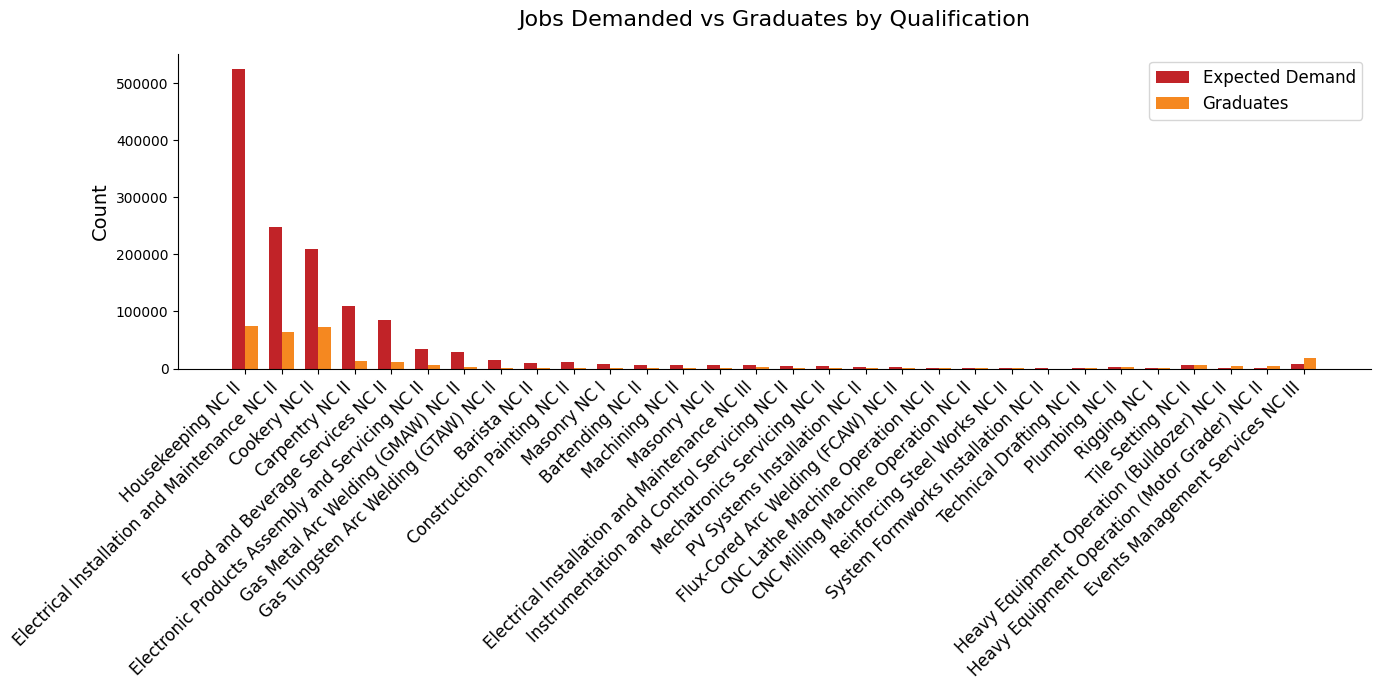

In [22]:
# Sort qualifications_df by Supply Gap (or any order you like)
qualifications_df = qualifications_df.sort_values(by='Supply Gap', ascending=False)

# Prepare data
sectors = qualifications_df.index.tolist()
jobs_demanded = qualifications_df['Expected Demand'].values
certified_individuals = qualifications_df['Graduates'].values

x = np.arange(len(sectors))  # x positions
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(14, 7))

# Plot bars
bars1 = ax.bar(x - width/2, jobs_demanded, width, label='Expected Demand', color='#c12328')
bars2 = ax.bar(x + width/2, certified_individuals, width, label='Graduates', color='#f58820ff')

# Labels and title
ax.set_ylabel('Count', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=45, ha='right', fontsize=12)
ax.set_title('Jobs Demanded vs Graduates by Qualification', fontsize=16, pad=20)

# Add legend
ax.legend(fontsize=12)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
merged_df['Program'].value_counts()

Program
HOUSEKEEPING NC II                                  1500
ELECTRICAL INSTALLATION AND MAINTENANCE NC II        800
COOKERY NC II                                        600
CARPENTRY NC II                                      450
FOOD AND BEVERAGE SERVICES NC II                     261
CONSTRUCTION PAINTING NC II                          110
GAS METAL ARC WELDING (GMAW) NC II                   100
ELECTRONIC PRODUCTS ASSEMBLY AND SERVICING NC II     100
TILE SETTING NC II                                    90
GAS TUNGSTEN ARC WELDING (GTAW) NC II                 60
MASONRY NC I                                          50
ELECTRICAL INSTALLATION AND MAINTENANCE NC III        50
MECHATRONICS SERVICING NC II                          40
PLUMBING NC II                                        40
EVENTS MANAGEMENT SERVICES NC III                     38
MASONRY NC II                                         30
MACHINING NC II                                       30
BARISTA NC II          